In [3]:
import pandas as pd
import numpy as np

In [5]:
jobs=pd.read_csv("jobs_dataset.csv")

In [9]:
jobs.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [11]:
jobs.shape

(50000, 14)

In [13]:
jobs.columns

Index(['job_id', 'job_title', 'company_type', 'industry', 'country', 'city',
       'remote_type', 'experience_level', 'min_experience_years',
       'salary_min_usd', 'salary_max_usd', 'employment_type', 'posted_year',
       'company_size'],
      dtype='object')

In [15]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                50000 non-null  object
 1   job_title             50000 non-null  object
 2   company_type          50000 non-null  object
 3   industry              50000 non-null  object
 4   country               50000 non-null  object
 5   city                  50000 non-null  object
 6   remote_type           50000 non-null  object
 7   experience_level      50000 non-null  object
 8   min_experience_years  50000 non-null  int64 
 9   salary_min_usd        50000 non-null  int64 
 10  salary_max_usd        50000 non-null  int64 
 11  employment_type       50000 non-null  object
 12  posted_year           50000 non-null  int64 
 13  company_size          50000 non-null  object
dtypes: int64(4), object(10)
memory usage: 5.3+ MB


In [17]:
jobs.dtypes

job_id                  object
job_title               object
company_type            object
industry                object
country                 object
city                    object
remote_type             object
experience_level        object
min_experience_years     int64
salary_min_usd           int64
salary_max_usd           int64
employment_type         object
posted_year              int64
company_size            object
dtype: object

In [19]:
jobs.isnull().sum()

job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
dtype: int64

In [23]:
jobs.duplicated().sum()

0

In [25]:
jobs["salary_avg_usd"]=(jobs["salary_max_usd"]+jobs["salary_min_usd"])/2

In [27]:
jobs.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,salary_avg_usd
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,64548.0
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,70201.0
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,162893.0
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,69980.0
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,115137.5


In [37]:
jobs["job_title"].value_counts()

job_title
MLOps Engineer               8439
AI Researcher                8415
Data Scientist               8410
Applied Scientist            8298
Data Analyst                 8260
Machine Learning Engineer    8178
Name: count, dtype: int64

In [33]:
jobs["experience_level"].value_counts()

experience_level
Mid       16695
Senior    16677
Entry     16628
Name: count, dtype: int64

In [39]:
jobs["country"].value_counts()

country
UK           8452
India        8350
Germany      8345
Canada       8303
Australia    8276
USA          8274
Name: count, dtype: int64

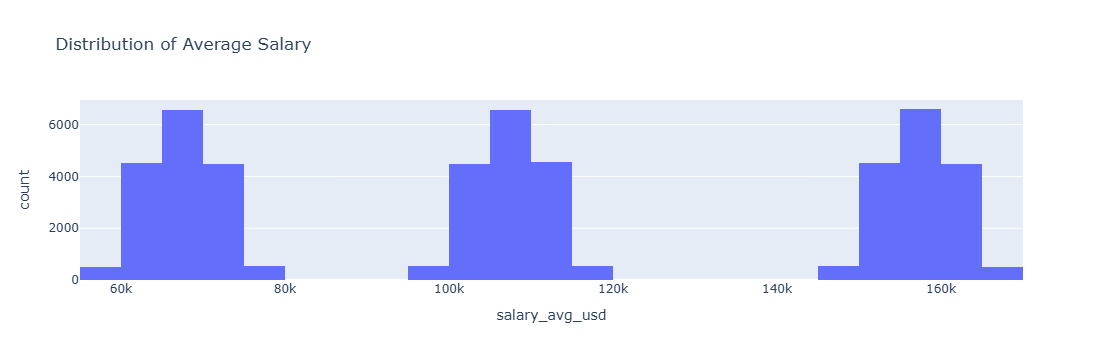

In [63]:
import plotly.express as px
fig = px.histogram(
    jobs,
    x="salary_avg_usd",
    nbins=50,
    title="Distribution of Average Salary"
)
fig.show()

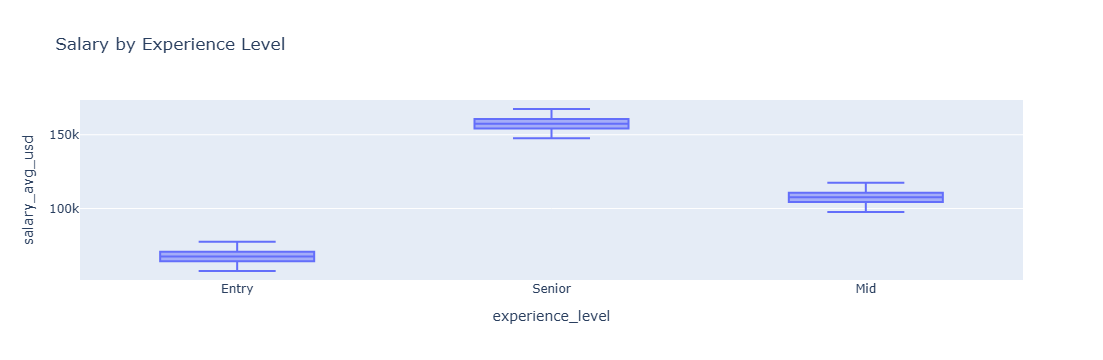

In [67]:
fig = px.box(
    jobs,
    x="experience_level",
    y="salary_avg_usd",
    title="Salary by Experience Level"
)
fig.show()

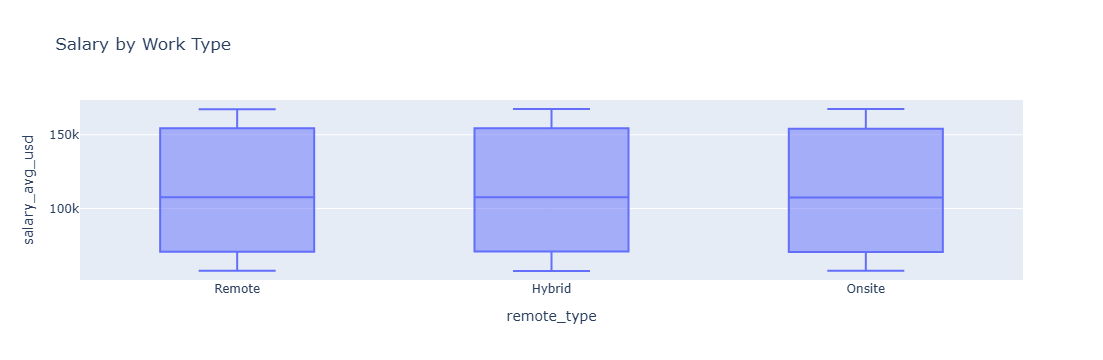

In [71]:
# Salary by remote type
fig = px.box(jobs, x="remote_type", y="salary_avg_usd", title="Salary by Work Type")
fig.show()

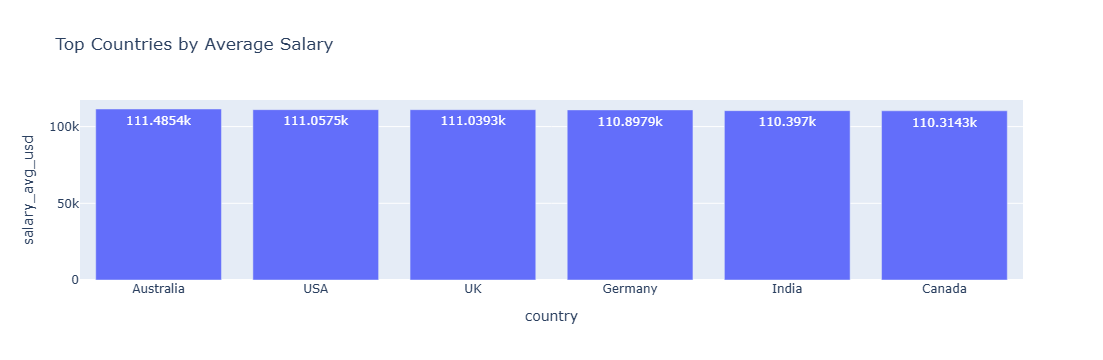

In [81]:
# Top countries by average salary
country_salary = (
    jobs.groupby("country", as_index=False)["salary_avg_usd"]
    .mean()
    .sort_values("salary_avg_usd", ascending=False)
    .head(15)
)
fig = px.bar(country_salary, x="country", y="salary_avg_usd",
             title="Top Countries by Average Salary", text_auto=True)
fig.show()

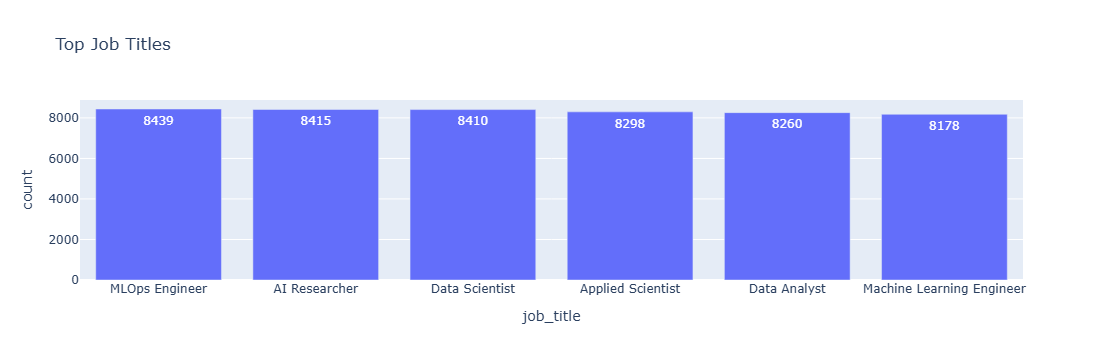

In [83]:
# Top job titles
top_jobs = jobs["job_title"].value_counts().head(15).reset_index()
top_jobs.columns = ["job_title", "count"]
fig = px.bar(top_jobs, x="job_title", y="count",
             title="Top Job Titles", text_auto=True)
fig.show()

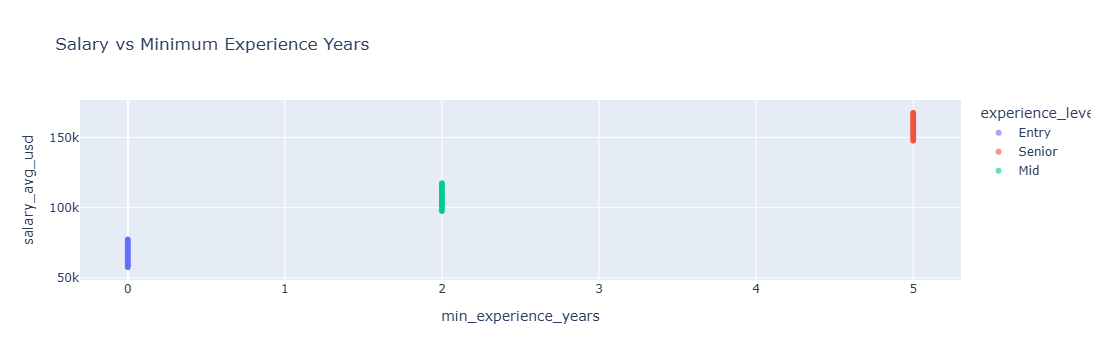

In [79]:
# Salary vs experience years
fig = px.scatter(jobs, x="min_experience_years", y="salary_avg_usd",
                 color="experience_level",
                 title="Salary vs Minimum Experience Years",
                 opacity=0.6)
fig.show()

In [45]:
features = [
    "job_title",
    "country",
    "experience_level",
    "min_experience_years",
    "remote_type",
    "company_size",
    "posted_year"
]

jobs_model = jobs[features + ["salary_avg_usd"]]

In [47]:
jobs_model

,job_title,country,experience_level,min_experience_years,remote_type,company_size,posted_year,salary_avg_usd
0,MLOps Engineer,Australia,Entry,0,Remote,Large,2023,64548.0
1,Data Analyst,Germany,Entry,0,Remote,Medium,2024,70201.0
2,MLOps Engineer,Canada,Senior,5,Remote,Large,2021,162893.0
3,Applied Scientist,Australia,Entry,0,Remote,Medium,2023,69980.0
4,Machine Learning Engineer,Australia,Mid,2,Hybrid,Large,2023,115137.5
...,...,...,...,...,...,...,...,...
49995,AI Researcher,Australia,Senior,5,Onsite,Medium,2023,159249.0
49996,Data Scientist,Canada,Senior,5,Onsite,Medium,2024,151120.5
49997,Data Analyst,USA,Entry,0,Onsite,Small,2022,69055.5
49998,Data Scientist,USA,Entry,0,Hybrid,Large,2020,69962.5


In [49]:
jobs_encoded = pd.get_dummies(jobs_model, drop_first=True)
jobs_encoded.head()

,min_experience_years,posted_year,salary_avg_usd,job_title_Applied Scientist,job_title_Data Analyst,job_title_Data Scientist,job_title_MLOps Engineer,job_title_Machine Learning Engineer,country_Canada,country_Germany,country_India,country_UK,country_USA,experience_level_Mid,experience_level_Senior,remote_type_Onsite,remote_type_Remote,company_size_Medium,company_size_Small
0,0,2023,64548.0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
1,0,2024,70201.0,False,True,False,False,False,False,True,False,False,False,False,False,False,True,True,False
2,5,2021,162893.0,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False
3,0,2023,69980.0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
4,2,2023,115137.5,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False


In [51]:
X = jobs_encoded.drop("salary_avg_usd", axis=1)
y = jobs_encoded["salary_avg_usd"]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
print(X_train.shape)
print(X_test.shape)

(40000, 18)
(10000, 18)
